# Gap-fill meteo variables

</br>

# Settings

## Data settings

In [1]:
SITE_LAT = 47.115833   # CH-FRU
SITE_LON = 8.537778  # CH-FRU
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)

## Imports

In [2]:
from datetime import datetime
import importlib.metadata
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
sns.set_theme('notebook')
import diive as dv
from diive.core.plotting.timeseries import TimeSeries
from diive.core.io.files import load_parquet, save_parquet
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.core.times.times import DetectFrequency
from diive.core.times.times import TimestampSanitizer
from diive.pkgs.createvar.potentialradiation import potrad
from diive.pkgs.corrections.offsetcorrection import remove_relativehumidity_offset, remove_radiation_zero_offset
from diive.pkgs.gapfilling.longterm import LongTermGapFillingXGBoostTS
from diive.pkgs.createvar.vpd import calc_vpd_from_ta_rh  # Used to calculate VPD
import warnings
from influxdb_client.client.warnings import MissingPivotFunction
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


</br>

# Load data from files

In [3]:
meteo = pd.read_csv("A2_TA_SWIN_RH_2024-2025.csv", index_col=0)
meteo.index = pd.to_datetime(meteo.index)
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1
TIMESTAMP_END,,,
2024-01-01 00:30:00,99.997990,0.0,0.063089
2024-01-01 01:00:00,98.689082,0.0,0.365761
2024-01-01 01:30:00,95.548050,0.0,0.326444
2024-01-01 02:00:00,89.946188,0.0,0.767750
2024-01-01 02:30:00,85.651175,0.0,1.136206
...,...,...,...
2025-12-31 22:00:00,95.027002,0.0,-8.169633
2025-12-31 22:30:00,95.338244,0.0,-8.388672
2025-12-31 23:00:00,92.821024,0.0,-8.424472


In [4]:
meteo.describe()

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1
count,33865.000000,34647.000000,33865.000000
mean,83.027027,139.358319,8.656682
std,17.306447,231.917063,7.433363
min,22.063927,0.000000,-10.233528
25%,72.437137,0.000000,3.432522
50%,88.318379,1.386259,8.346361
75%,98.255546,192.303599,13.900628
max,99.997990,1104.207108,29.801215


</br>

## Sanitize timestamp

In [5]:
meteo = TimestampSanitizer(data=meteo, output_middle_timestamp=True).get()
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1
TIMESTAMP_MIDDLE,,,
2024-01-01 00:15:00,99.997990,0.0,0.063089
2024-01-01 00:45:00,98.689082,0.0,0.365761
2024-01-01 01:15:00,95.548050,0.0,0.326444
2024-01-01 01:45:00,89.946188,0.0,0.767750
2024-01-01 02:15:00,85.651175,0.0,1.136206
...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633
2025-12-31 22:15:00,95.338244,0.0,-8.388672
2025-12-31 22:45:00,92.821024,0.0,-8.424472


</br>

# Gap-filling

## SW_IN_T1_1_1

### Target and features

In [6]:
TARGET = "SW_IN_T1_1_1"
subset = pd.DataFrame()
subset[TARGET] = meteo[[TARGET]].copy()
subset['SW_IN_POT'] = potrad(timestamp_index=subset.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
subset

,SW_IN_T1_1_1,SW_IN_POT
TIMESTAMP_MIDDLE,,
2024-01-01 00:15:00,0.0,0.0
2024-01-01 00:45:00,0.0,0.0
2024-01-01 01:15:00,0.0,0.0
2024-01-01 01:45:00,0.0,0.0
2024-01-01 02:15:00,0.0,0.0
...,...,...
2025-12-31 21:45:00,0.0,0.0
2025-12-31 22:15:00,0.0,0.0
2025-12-31 22:45:00,0.0,0.0


### Initialize gap-filling

In [7]:
ltxgb = LongTermGapFillingXGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=0,
    # features_lag=[-1, -1],
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=True,
    perm_n_repeats=9,
    n_estimators=1000,
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=50,
    max_depth=6,
    # max_delta_step=0,
    # subsample=1,
    learning_rate=0.3,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy=0,
    grow_policy='lossguide',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 35088.


### Initialize yearly models

In [8]:
ltxgb.create_yearpools()
ltxgb.initialize_yearly_models()

[neighboring_years] Assigned [2024, 2025] to data pool for 2024.
[neighboring_years] Assigned [2024, 2025] to data pool for 2025.
Initializing model for 2024 ...
Initializing model for 2025 ...


### Reduce features across years

In [9]:
ltxgb.reduce_features_across_years()

---
Reducing features based on permutation importance for year 2024 ...

[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:182.86375	validation_1-rmse:182.86375
[1]	validation_0-rmse:152.01608	validation_1-rmse:152.01608
[2]	validation_0-rmse:133.74401	validation_1-rmse:133.74401
[3]	validation_0-rmse:122.68811	validation_1-rmse:122.68811
[4]	validation_0-rmse:114.96555	validation_1-rmse:114.96555
[5]	validation_0-rmse:110.95999	validation_1-rmse:110.95999
[6]	validation_0-rmse:107.82793	validation_1-rmse:107.82793
[7]	validation_0-rmse:104.83110	validation_1-rmse:104.83110
[8]	validation_0-rmse:103.27027	validation_1-rmse:103.27027
[9]	validation_0-rmse:101.43746	validation_1-rmse:101.43746
[10]	validation_0-rmse:99.83832	validation_1-rmse:99.83832
[11]	validation_0-rmse:98.59963	validation_1-rmse:98.59963
[12]	validation_0-rmse:97.23265	validation_1-rmse:97.23265
[13]	validation_0-rmse:96.04480	validation_1-rmse:96.04480
[14]	validation

### Train models and fill gaps

In [10]:
ltxgb.fillgaps()


Training model for 2024 ...

Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2024-01-01 00:45:00 and 2025-12-31 23:45:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:182.87195	validation_1-rmse:184.09799
[1]	validation_0-rmse:152.31441	validation_1-rmse:154.38889
[2]	validation_0-rmse:134.00023	validation_1-rmse:136.31641
[3]	validation_0-rmse:122.66497	validation_1-rmse:125.25023
[4]	validation_0-rmse:115.39942	validation_1-rmse:118.19294
[5]	validation_0-rmse:110.42722	validation_1-rmse:113.68378
[6]	validation_0-rmse:106.85021	validation_1-rmse:110.28516
[7]	validation_0-rmse:104.40624	validation_1-rmse:108.22346
[8]	validation_0-rmse:102.55780	validation_1-rmse:106.82127
[9]	validation_0-rmse:100.41538	validation_1-rmse:105.38541
[10]	validation_0-rmse:99.14125	validation_1-rmse:104.11553
[11]	validation_0-rmse:98.07998	validation_1-rmse:103.59276
[12]	validation_0-rmse:97.10536	validation_1-rmse:102.7616

### Results: yearly scores

In [11]:
scores = pd.DataFrame(ltxgb.scores_)
scores.style.format("{:.4f}")

,2024,2025
mae,28.6461,28.6461
medae,7.4210,7.4210
mse,3345.1436,3345.1436
rmse,57.8372,57.8372
mape,9247735677997066.0000,9247735677997066.0000
maxe,820.6491,820.6491
r2,0.9378,0.9378


### Results: feature importances

In [12]:
ltxgb.feature_importances_yearly_

{'2024':                PERM_IMPORTANCE   PERM_SD
 SW_IN_POT             1.620904  0.007188
 .RECORDNUMBER         0.225950  0.004080
 .DOY_COS              0.219972  0.001888
 .DOY_SIN              0.164984  0.003345
 .YEARDOY              0.127724  0.001590
 .WEEK_SIN             0.093079  0.001400,
 '2025':                PERM_IMPORTANCE   PERM_SD
 SW_IN_POT             1.620904  0.007188
 .RECORDNUMBER         0.225950  0.004080
 .DOY_COS              0.219972  0.001888
 .DOY_SIN              0.164984  0.003345
 .YEARDOY              0.127724  0.001590
 .WEEK_SIN             0.093079  0.001400}

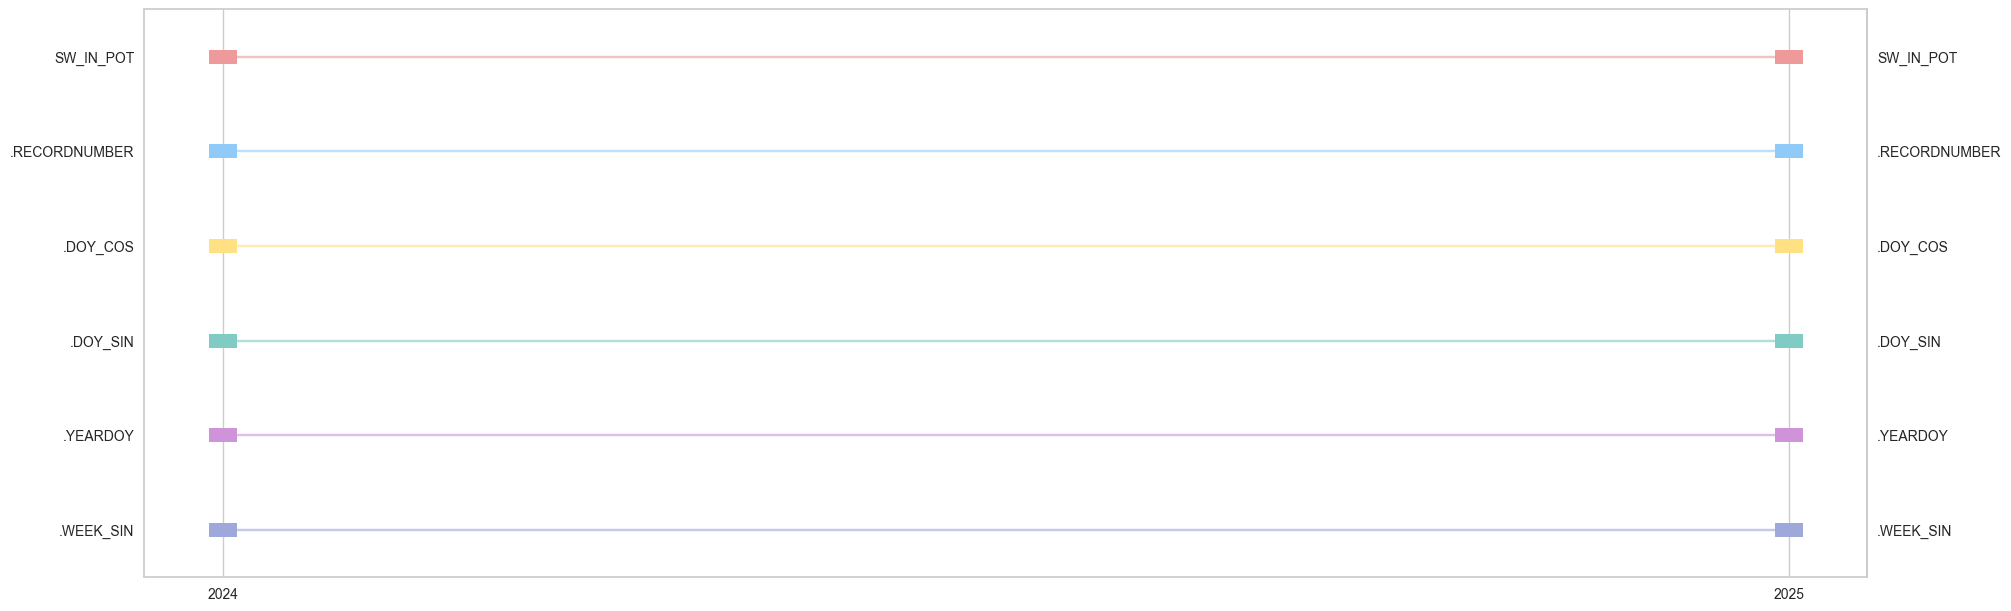

In [13]:
ltxgb.showplot_feature_ranks_per_year()

### Results: plot gap-filled time series

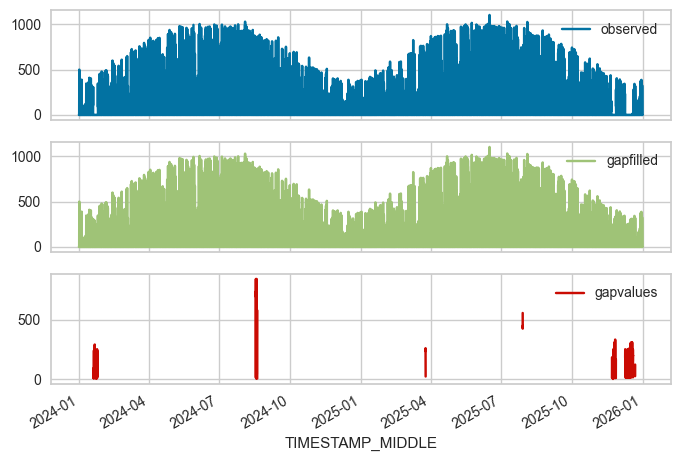

In [14]:
observed = subset[TARGET]
gapfilled = ltxgb.gapfilled_
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

### Add gap-filled series to dataframe

In [15]:
meteo[gapfilled.name] = gapfilled

### Plot time series

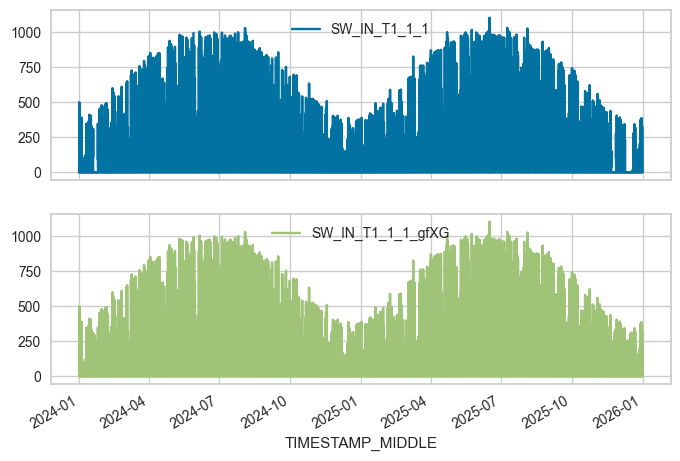

In [16]:
meteo[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

### Correction: Remove zero offset < 0 from `SW_IN_T1_47_1_gfXG`
- Additional correction needed because gap-filling introduced values < 0

In [17]:
meteo[[TARGET, gapfilled.name]].describe()

,SW_IN_T1_1_1,SW_IN_T1_1_1_gfXG
count,34647.000000,35088.000000
mean,139.358319,140.018407
std,231.917063,231.267259
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.386259,2.456038
75%,192.303599,194.514006
max,1104.207108,1104.207108


[remove_radiation_zero_offset]  running remove_radiation_zero_offset ...


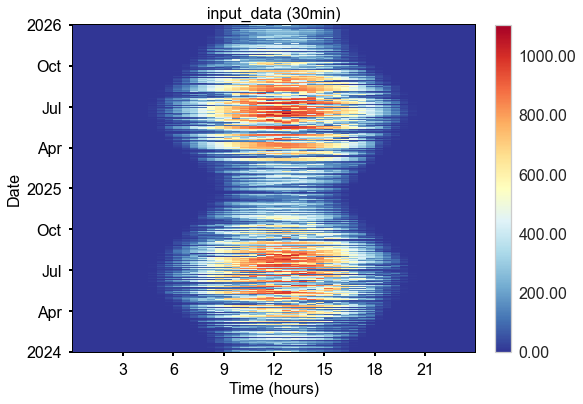

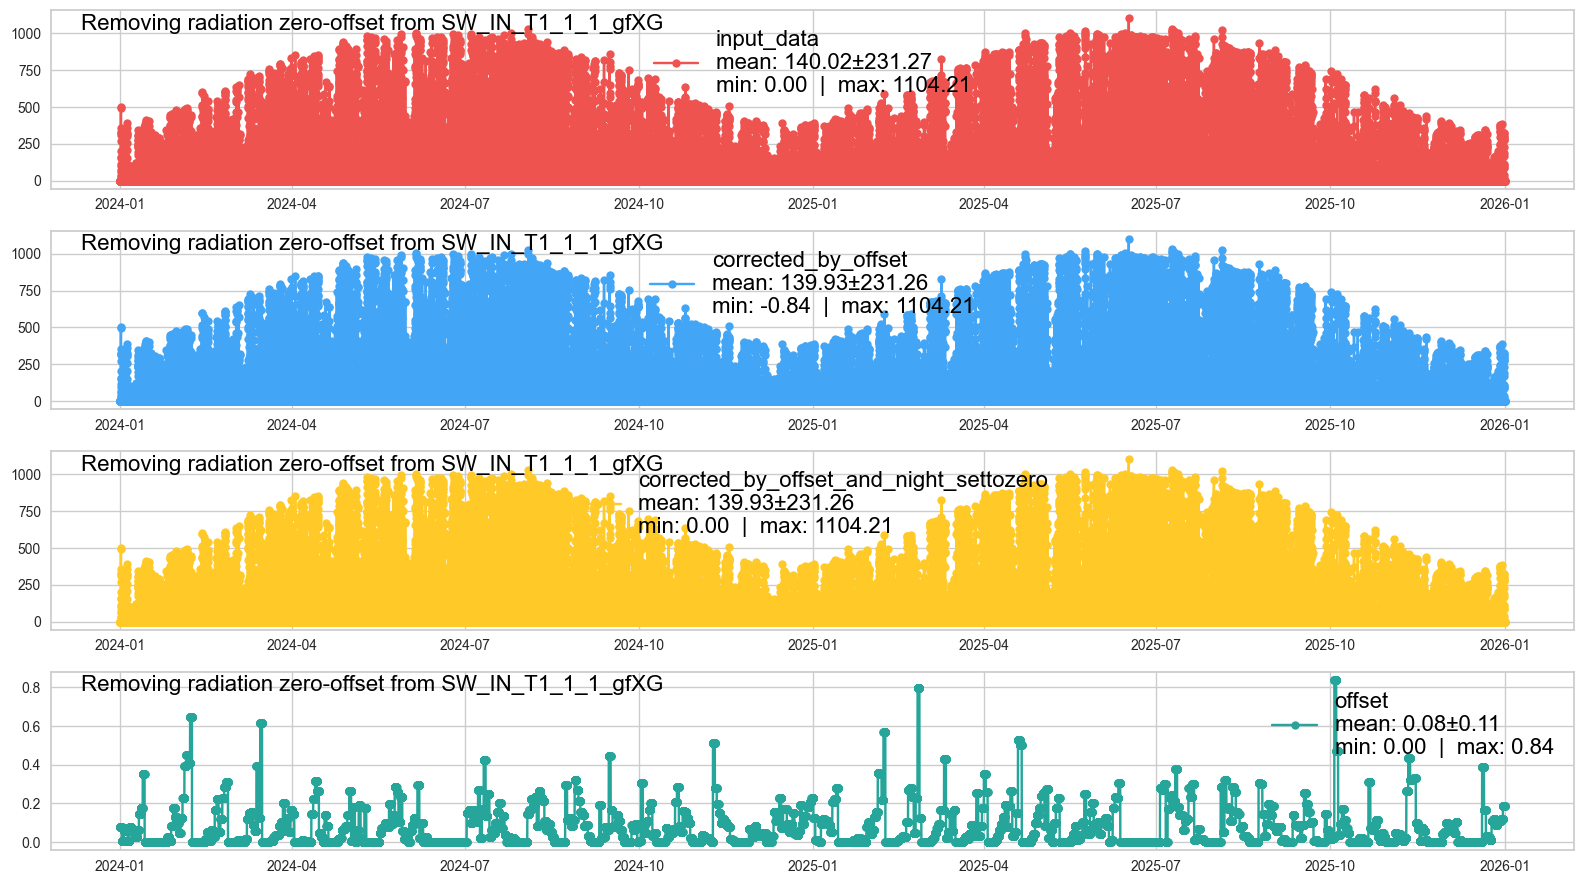

In [18]:
_swin = meteo['SW_IN_T1_1_1_gfXG'].copy()
_swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
meteo['SW_IN_T1_1_1_gfXG'] = np.nan
meteo['SW_IN_T1_1_1_gfXG'] = _swin_corrected

### Final dataframe

In [19]:
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG
TIMESTAMP_MIDDLE,,,,
2024-01-01 00:15:00,99.997990,0.0,0.063089,0.0
2024-01-01 00:45:00,98.689082,0.0,0.365761,0.0
2024-01-01 01:15:00,95.548050,0.0,0.326444,0.0
2024-01-01 01:45:00,89.946188,0.0,0.767750,0.0
2024-01-01 02:15:00,85.651175,0.0,1.136206,0.0
...,...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633,0.0
2025-12-31 22:15:00,95.338244,0.0,-8.388672,0.0
2025-12-31 22:45:00,92.821024,0.0,-8.424472,0.0


In [20]:
meteo.describe()

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG
count,33865.000000,34647.000000,33865.000000,35088.000000
mean,83.027027,139.358319,8.656682,139.934098
std,17.306447,231.917063,7.433363,231.260334
min,22.063927,0.000000,-10.233528,0.000000
25%,72.437137,0.000000,3.432522,0.000000
50%,88.318379,1.386259,8.346361,0.000000
75%,98.255546,192.303599,13.900628,194.433048
max,99.997990,1104.207108,29.801215,1104.207108


</br>

</br>

</br>

## TA_T1_2_1

### Target and features

In [21]:
TARGET = "TA_T1_2_1"
subset = pd.DataFrame()
subset[TARGET] = meteo[[TARGET]].copy()
subset['SW_IN_T1_1_1_gfXG'] = meteo['SW_IN_T1_1_1_gfXG'].copy()
# subset['SW_IN_POT'] = potrad(timestamp_index=subset.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
subset

,TA_T1_2_1,SW_IN_T1_1_1_gfXG
TIMESTAMP_MIDDLE,,
2024-01-01 00:15:00,0.063089,0.0
2024-01-01 00:45:00,0.365761,0.0
2024-01-01 01:15:00,0.326444,0.0
2024-01-01 01:45:00,0.767750,0.0
2024-01-01 02:15:00,1.136206,0.0
...,...,...
2025-12-31 21:45:00,-8.169633,0.0
2025-12-31 22:15:00,-8.388672,0.0
2025-12-31 22:45:00,-8.424472,0.0


### Initialize gap-filling

In [22]:
ltxgb = LongTermGapFillingXGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=0,
    # features_lag=[-1, -1],
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=True,
    perm_n_repeats=9,
    n_estimators=1000,
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=50,
    max_depth=6,
    # max_delta_step=0,
    # subsample=1,
    learning_rate=0.3,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy=0,
    grow_policy='lossguide',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 35088.


### Initialize yearly models

In [23]:
ltxgb.create_yearpools()
ltxgb.initialize_yearly_models()

[neighboring_years] Assigned [2024, 2025] to data pool for 2024.
[neighboring_years] Assigned [2024, 2025] to data pool for 2025.
Initializing model for 2024 ...
Initializing model for 2025 ...


### Reduce features across years

In [24]:
ltxgb.reduce_features_across_years()

---
Reducing features based on permutation importance for year 2024 ...

[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:5.75611	validation_1-rmse:5.75611
[1]	validation_0-rmse:4.65904	validation_1-rmse:4.65904
[2]	validation_0-rmse:3.98131	validation_1-rmse:3.98131
[3]	validation_0-rmse:3.48047	validation_1-rmse:3.48047
[4]	validation_0-rmse:3.18460	validation_1-rmse:3.18460
[5]	validation_0-rmse:2.96859	validation_1-rmse:2.96859
[6]	validation_0-rmse:2.82830	validation_1-rmse:2.82830
[7]	validation_0-rmse:2.72970	validation_1-rmse:2.72970
[8]	validation_0-rmse:2.64125	validation_1-rmse:2.64125
[9]	validation_0-rmse:2.57820	validation_1-rmse:2.57820
[10]	validation_0-rmse:2.54149	validation_1-rmse:2.54149
[11]	validation_0-rmse:2.51330	validation_1-rmse:2.51330
[12]	validation_0-rmse:2.46914	validation_1-rmse:2.46914
[13]	validation_0-rmse:2.43197	validation_1-rmse:2.43197
[14]	validation_0-rmse:2.38047	validation_1-rmse:2.38047
[15]	v

### Train models and fill gaps

In [25]:
ltxgb.fillgaps()


Training model for 2024 ...

Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2024-01-01 00:45:00 and 2025-12-31 23:45:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:5.75611	validation_1-rmse:5.74959
[1]	validation_0-rmse:4.65904	validation_1-rmse:4.65516
[2]	validation_0-rmse:3.98131	validation_1-rmse:3.98620
[3]	validation_0-rmse:3.48049	validation_1-rmse:3.48385
[4]	validation_0-rmse:3.18467	validation_1-rmse:3.19534
[5]	validation_0-rmse:2.96866	validation_1-rmse:2.98783
[6]	validation_0-rmse:2.82836	validation_1-rmse:2.84795
[7]	validation_0-rmse:2.72975	validation_1-rmse:2.75737
[8]	validation_0-rmse:2.64183	validation_1-rmse:2.68119
[9]	validation_0-rmse:2.57843	validation_1-rmse:2.61679
[10]	validation_0-rmse:2.54125	validation_1-rmse:2.58346
[11]	validation_0-rmse:2.51581	validation_1-rmse:2.56130
[12]	validation_0-rmse:2.47124	validation_1-rmse:2.51666
[13]	validation_0-rmse:2.43295	validation_1-rms

### Results: yearly scores

In [26]:
scores = pd.DataFrame(ltxgb.scores_)
scores.style.format("{:.4f}")

,2024,2025
mae,0.3099,0.3099
medae,0.1963,0.1963
mse,0.2338,0.2338
rmse,0.4836,0.4836
mape,0.2025,0.2025
maxe,7.0428,7.0428
r2,0.9958,0.9958


### Results: feature importances

In [27]:
ltxgb.feature_importances_yearly_

{'2024':                    PERM_IMPORTANCE   PERM_SD
 .DOY_COS                  1.617952  0.007479
 .DOY_SIN                  0.268719  0.001017
 .RECORDNUMBER             0.267723  0.001558
 SW_IN_T1_1_1_gfXG         0.154635  0.001116
 .YEARDOY                  0.127753  0.000715
 .HOUR_SIN                 0.073451  0.000444
 .WEEK_SIN                 0.056529  0.000572
 .WEEK_COS                 0.034966  0.000277
 .YEARWEEK                 0.027454  0.000204
 .HOUR_COS                 0.017182  0.000208
 .MONTH_SIN                0.009516  0.000085
 .SEASON_COS               0.009110  0.000112
 .YEARMONTH                0.003591  0.000061,
 '2025':                    PERM_IMPORTANCE   PERM_SD
 .DOY_COS                  1.617952  0.007479
 .DOY_SIN                  0.268719  0.001017
 .RECORDNUMBER             0.267723  0.001558
 SW_IN_T1_1_1_gfXG         0.154635  0.001116
 .YEARDOY                  0.127753  0.000715
 .HOUR_SIN                 0.073451  0.000444
 .WEEK_SIN       

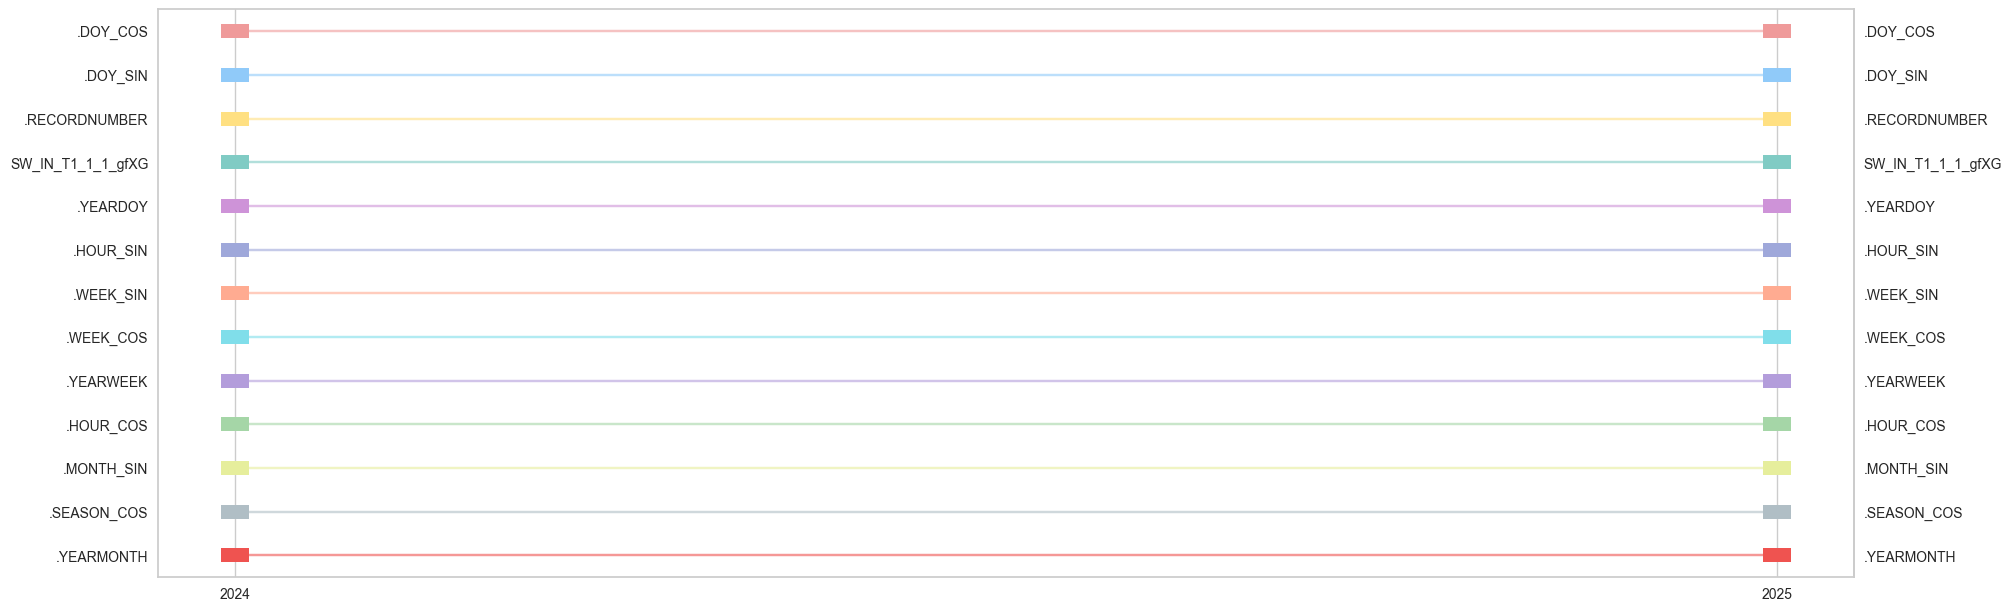

In [28]:
ltxgb.showplot_feature_ranks_per_year()

### Results: plot gap-filled time series

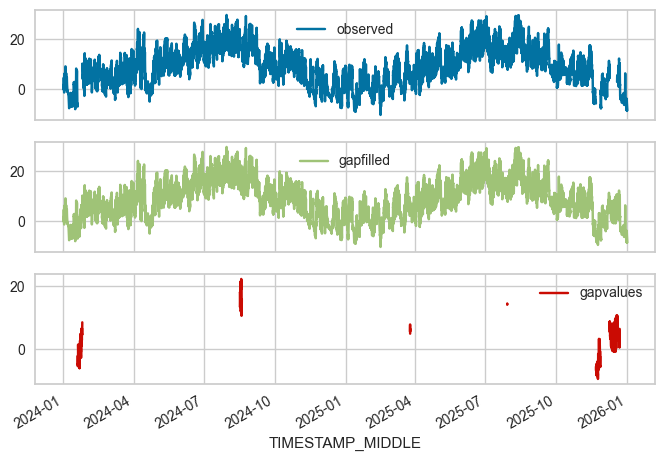

In [29]:
observed = subset[TARGET]
gapfilled = ltxgb.gapfilled_
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

### Add gap-filled series to dataframe

In [30]:
meteo[gapfilled.name] = gapfilled

### Plot time series

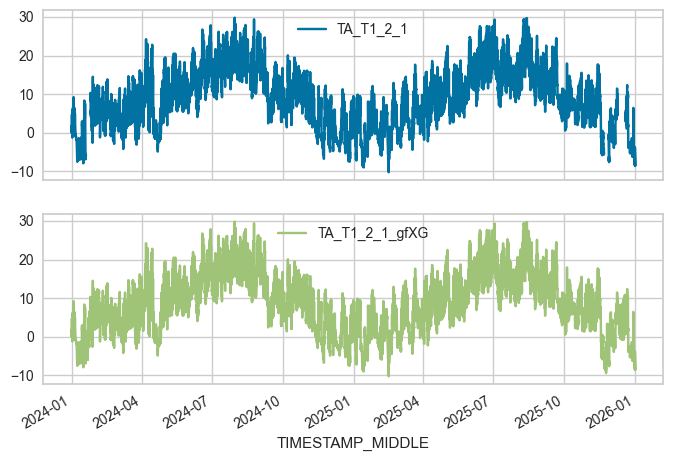

In [31]:
meteo[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

### Final dataframe

In [32]:
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG
TIMESTAMP_MIDDLE,,,,,
2024-01-01 00:15:00,99.997990,0.0,0.063089,0.0,0.063089
2024-01-01 00:45:00,98.689082,0.0,0.365761,0.0,0.365761
2024-01-01 01:15:00,95.548050,0.0,0.326444,0.0,0.326444
2024-01-01 01:45:00,89.946188,0.0,0.767750,0.0,0.767750
2024-01-01 02:15:00,85.651175,0.0,1.136206,0.0,1.136206
...,...,...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633,0.0,-8.169633
2025-12-31 22:15:00,95.338244,0.0,-8.388672,0.0,-8.388672
2025-12-31 22:45:00,92.821024,0.0,-8.424472,0.0,-8.424472


In [33]:
meteo.describe()

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG
count,33865.000000,34647.000000,33865.000000,35088.000000,35088.000000
mean,83.027027,139.358319,8.656682,139.934098,8.436064
std,17.306447,231.917063,7.433363,231.260334,7.493192
min,22.063927,0.000000,-10.233528,0.000000,-10.233528
25%,72.437137,0.000000,3.432522,0.000000,3.134851
50%,88.318379,1.386259,8.346361,0.000000,8.102733
75%,98.255546,192.303599,13.900628,194.433048,13.754270
max,99.997990,1104.207108,29.801215,1104.207108,29.801215


</br>

</br>

## VPD

### Calculate VPD

In [34]:
vpd = calc_vpd_from_ta_rh(df=meteo, ta_col='TA_T1_2_1', rh_col='RH_T1_2_1')
vpd

TIMESTAMP_MIDDLE
2024-01-01 00:15:00    0.000012
2024-01-01 00:45:00    0.008223
2024-01-01 01:15:00    0.027846
2024-01-01 01:45:00    0.064932
2024-01-01 02:15:00    0.095174
                         ...   
2025-12-31 21:45:00    0.016381
2025-12-31 22:15:00    0.015095
2025-12-31 22:45:00    0.023180
2025-12-31 23:15:00    0.024910
2025-12-31 23:45:00    0.031322
Freq: 30min, Name: VPD, Length: 35088, dtype: float64

In [35]:
meteo['VPD_T1_2_1'] = vpd.copy()
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG,VPD_T1_2_1
TIMESTAMP_MIDDLE,,,,,,
2024-01-01 00:15:00,99.997990,0.0,0.063089,0.0,0.063089,0.000012
2024-01-01 00:45:00,98.689082,0.0,0.365761,0.0,0.365761,0.008223
2024-01-01 01:15:00,95.548050,0.0,0.326444,0.0,0.326444,0.027846
2024-01-01 01:45:00,89.946188,0.0,0.767750,0.0,0.767750,0.064932
2024-01-01 02:15:00,85.651175,0.0,1.136206,0.0,1.136206,0.095174
...,...,...,...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633,0.0,-8.169633,0.016381
2025-12-31 22:15:00,95.338244,0.0,-8.388672,0.0,-8.388672,0.015095
2025-12-31 22:45:00,92.821024,0.0,-8.424472,0.0,-8.424472,0.023180


### Target and features

In [36]:
TARGET = "VPD_T1_2_1"
subset = pd.DataFrame()
subset[TARGET] = meteo[[TARGET]].copy()
subset['SW_IN_T1_1_1_gfXG'] = meteo['SW_IN_T1_1_1_gfXG'].copy()
subset['TA_T1_2_1_gfXG'] = meteo['TA_T1_2_1_gfXG'].copy()
subset

,VPD_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG
TIMESTAMP_MIDDLE,,,
2024-01-01 00:15:00,0.000012,0.0,0.063089
2024-01-01 00:45:00,0.008223,0.0,0.365761
2024-01-01 01:15:00,0.027846,0.0,0.326444
2024-01-01 01:45:00,0.064932,0.0,0.767750
2024-01-01 02:15:00,0.095174,0.0,1.136206
...,...,...,...
2025-12-31 21:45:00,0.016381,0.0,-8.169633
2025-12-31 22:15:00,0.015095,0.0,-8.388672
2025-12-31 22:45:00,0.023180,0.0,-8.424472


### Initialize gap-filling

In [37]:
ltxgb = LongTermGapFillingXGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=0,
    # features_lag=[-1, -1],
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=True,
    perm_n_repeats=9,
    n_estimators=1000,
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=50,
    max_depth=6,
    # max_delta_step=0,
    # subsample=1,
    learning_rate=0.3,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy=0,
    grow_policy='lossguide',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 35088.


### Initialize yearly models

In [38]:
ltxgb.create_yearpools()
ltxgb.initialize_yearly_models()

[neighboring_years] Assigned [2024, 2025] to data pool for 2024.
[neighboring_years] Assigned [2024, 2025] to data pool for 2025.
Initializing model for 2024 ...
Initializing model for 2025 ...


### Reduce features across years

In [39]:
ltxgb.reduce_features_across_years()

---
Reducing features based on permutation importance for year 2024 ...

[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:0.26671	validation_1-rmse:0.26671
[1]	validation_0-rmse:0.20990	validation_1-rmse:0.20990
[2]	validation_0-rmse:0.17257	validation_1-rmse:0.17257
[3]	validation_0-rmse:0.14968	validation_1-rmse:0.14968
[4]	validation_0-rmse:0.13431	validation_1-rmse:0.13431
[5]	validation_0-rmse:0.12491	validation_1-rmse:0.12491
[6]	validation_0-rmse:0.11821	validation_1-rmse:0.11821
[7]	validation_0-rmse:0.11370	validation_1-rmse:0.11370
[8]	validation_0-rmse:0.10963	validation_1-rmse:0.10963
[9]	validation_0-rmse:0.10618	validation_1-rmse:0.10618
[10]	validation_0-rmse:0.10382	validation_1-rmse:0.10382
[11]	validation_0-rmse:0.10151	validation_1-rmse:0.10151
[12]	validation_0-rmse:0.09981	validation_1-rmse:0.09981
[13]	validation_0-rmse:0.09695	validation_1-rmse:0.09695
[14]	validation_0-rmse:0.09547	validation_1-rmse:0.09547
[15]	v

### Train models and fill gaps

In [40]:
ltxgb.fillgaps()


Training model for 2024 ...

Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2024-01-01 00:45:00 and 2025-12-31 23:45:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:0.26671	validation_1-rmse:0.26975
[1]	validation_0-rmse:0.20990	validation_1-rmse:0.21203
[2]	validation_0-rmse:0.17257	validation_1-rmse:0.17485
[3]	validation_0-rmse:0.14970	validation_1-rmse:0.15264
[4]	validation_0-rmse:0.13434	validation_1-rmse:0.13750
[5]	validation_0-rmse:0.12502	validation_1-rmse:0.12822
[6]	validation_0-rmse:0.11830	validation_1-rmse:0.12198
[7]	validation_0-rmse:0.11323	validation_1-rmse:0.11734
[8]	validation_0-rmse:0.10902	validation_1-rmse:0.11322
[9]	validation_0-rmse:0.10538	validation_1-rmse:0.10970
[10]	validation_0-rmse:0.10250	validation_1-rmse:0.10695
[11]	validation_0-rmse:0.09914	validation_1-rmse:0.10359
[12]	validation_0-rmse:0.09740	validation_1-rmse:0.10222
[13]	validation_0-rmse:0.09607	validation_1-rms

### Results: yearly scores

In [41]:
scores = pd.DataFrame(ltxgb.scores_)
scores.style.format("{:.4f}")

,2024,2025
mae,0.0129,0.0129
medae,0.0064,0.0064
mse,0.0007,0.0007
rmse,0.0258,0.0258
mape,45.4727,45.4727
maxe,0.6494,0.6494
r2,0.9946,0.9946


### Results: feature importances

In [42]:
ltxgb.feature_importances_yearly_

{'2024':                    PERM_IMPORTANCE       PERM_SD
 TA_T1_2_1_gfXG            3.372028  1.525030e-02
 .DOY_COS                  0.526982  5.219193e-03
 .DOY_SIN                  0.225224  2.047807e-03
 .RECORDNUMBER             0.136811  1.541106e-03
 .YEARDOY                  0.096149  6.874385e-04
 .WEEK_SIN                 0.044946  3.900669e-04
 SW_IN_T1_1_1_gfXG         0.036858  4.958802e-04
 .WEEK_COS                 0.027794  3.201691e-04
 .HOUR_COS                 0.023771  1.003411e-04
 .HOUR_SIN                 0.019508  2.492788e-04
 .YEARWEEK                 0.015798  1.619540e-04
 .MONTH_SIN                0.013196  1.914242e-04
 .SEASON_COS               0.011677  1.687753e-04
 .MONTH_COS                0.006956  8.520192e-05
 .SEASON_SIN               0.000017  9.456618e-07,
 '2025':                    PERM_IMPORTANCE       PERM_SD
 TA_T1_2_1_gfXG            3.372028  1.525030e-02
 .DOY_COS                  0.526982  5.219193e-03
 .DOY_SIN                  0.2252

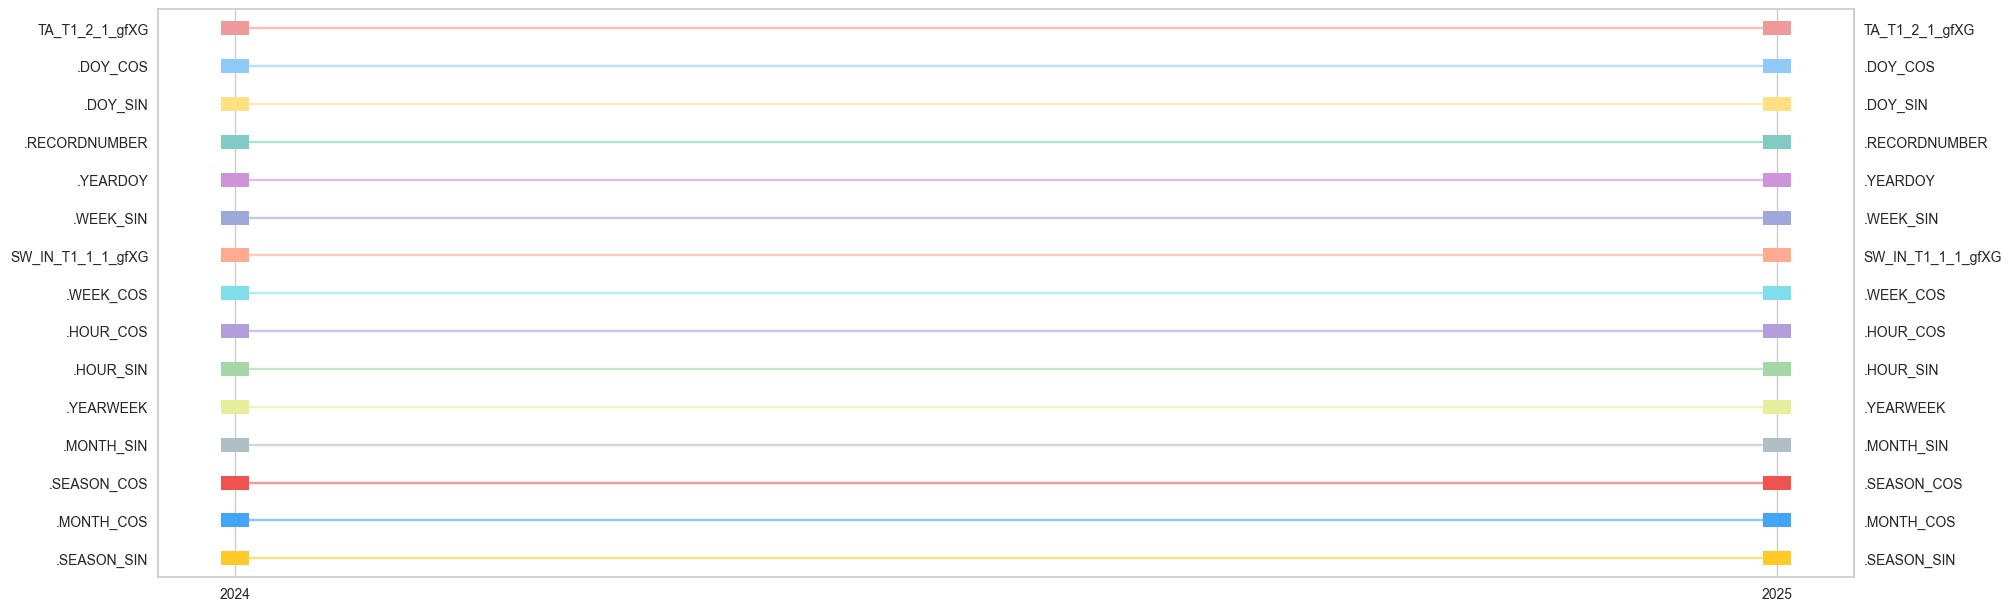

In [43]:
ltxgb.showplot_feature_ranks_per_year()

### Results: plot gap-filled time series

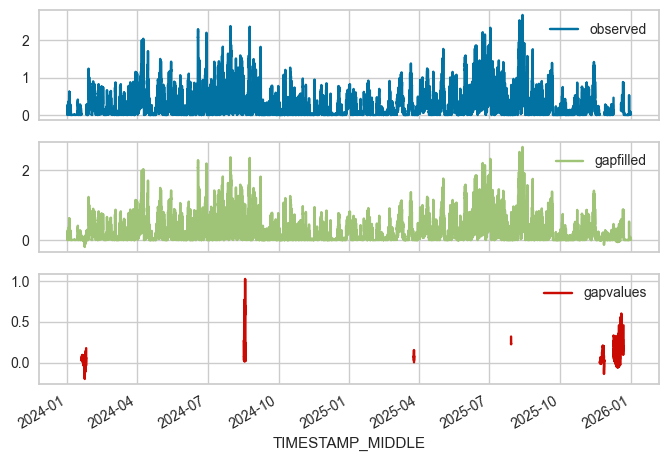

In [44]:
observed = subset[TARGET]
gapfilled = ltxgb.gapfilled_
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

### Add gap-filled series to dataframe

In [45]:
meteo[gapfilled.name] = gapfilled

### Plot time series

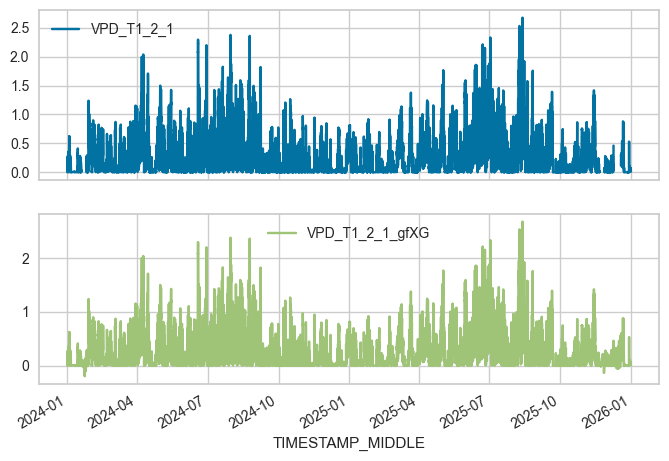

In [46]:
meteo[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

### Set values < 0 to minimum

In [47]:
smallest_positive_vpd = meteo[gapfilled.name][meteo[gapfilled.name] > 0].min()
smallest_positive_vpd

np.float64(8.270101659411746e-06)

In [48]:
vpd_minimum = meteo[gapfilled.name].min()
print(f"Gap-filled VPD minimum before correction: {vpd_minimum}")
meteo[gapfilled.name].loc[meteo[gapfilled.name] < 0] = smallest_positive_vpd
vpd_minimum = meteo[gapfilled.name].min()
print(f"Gap-filled VPD minimum after correction: {vpd_minimum}")

Gap-filled VPD minimum before correction: -0.19875052571296692
Gap-filled VPD minimum after correction: 8.270101659411746e-06


### Final dataframe

In [49]:
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG,VPD_T1_2_1,VPD_T1_2_1_gfXG
TIMESTAMP_MIDDLE,,,,,,,
2024-01-01 00:15:00,99.997990,0.0,0.063089,0.0,0.063089,0.000012,0.000012
2024-01-01 00:45:00,98.689082,0.0,0.365761,0.0,0.365761,0.008223,0.008223
2024-01-01 01:15:00,95.548050,0.0,0.326444,0.0,0.326444,0.027846,0.027846
2024-01-01 01:45:00,89.946188,0.0,0.767750,0.0,0.767750,0.064932,0.064932
2024-01-01 02:15:00,85.651175,0.0,1.136206,0.0,1.136206,0.095174,0.095174
...,...,...,...,...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633,0.0,-8.169633,0.016381,0.016381
2025-12-31 22:15:00,95.338244,0.0,-8.388672,0.0,-8.388672,0.015095,0.015095
2025-12-31 22:45:00,92.821024,0.0,-8.424472,0.0,-8.424472,0.023180,0.023180


In [50]:
meteo.describe()

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG,VPD_T1_2_1,VPD_T1_2_1_gfXG
count,33865.000000,34647.000000,33865.000000,35088.000000,35088.000000,33865.000000,35088.000000
mean,83.027027,139.358319,8.656682,139.934098,8.436064,0.266297,0.260633
std,17.306447,231.917063,7.433363,231.260334,7.493192,0.351806,0.347890
min,22.063927,0.000000,-10.233528,0.000000,-10.233528,0.000008,0.000008
25%,72.437137,0.000000,3.432522,0.000000,3.134851,0.013451,0.013223
50%,88.318379,1.386259,8.346361,0.000000,8.102733,0.125023,0.120013
75%,98.255546,192.303599,13.900628,194.433048,13.754270,0.384723,0.374153
max,99.997990,1104.207108,29.801215,1104.207108,29.801215,2.676927,2.676927


</br>

</br>

# Plot time series

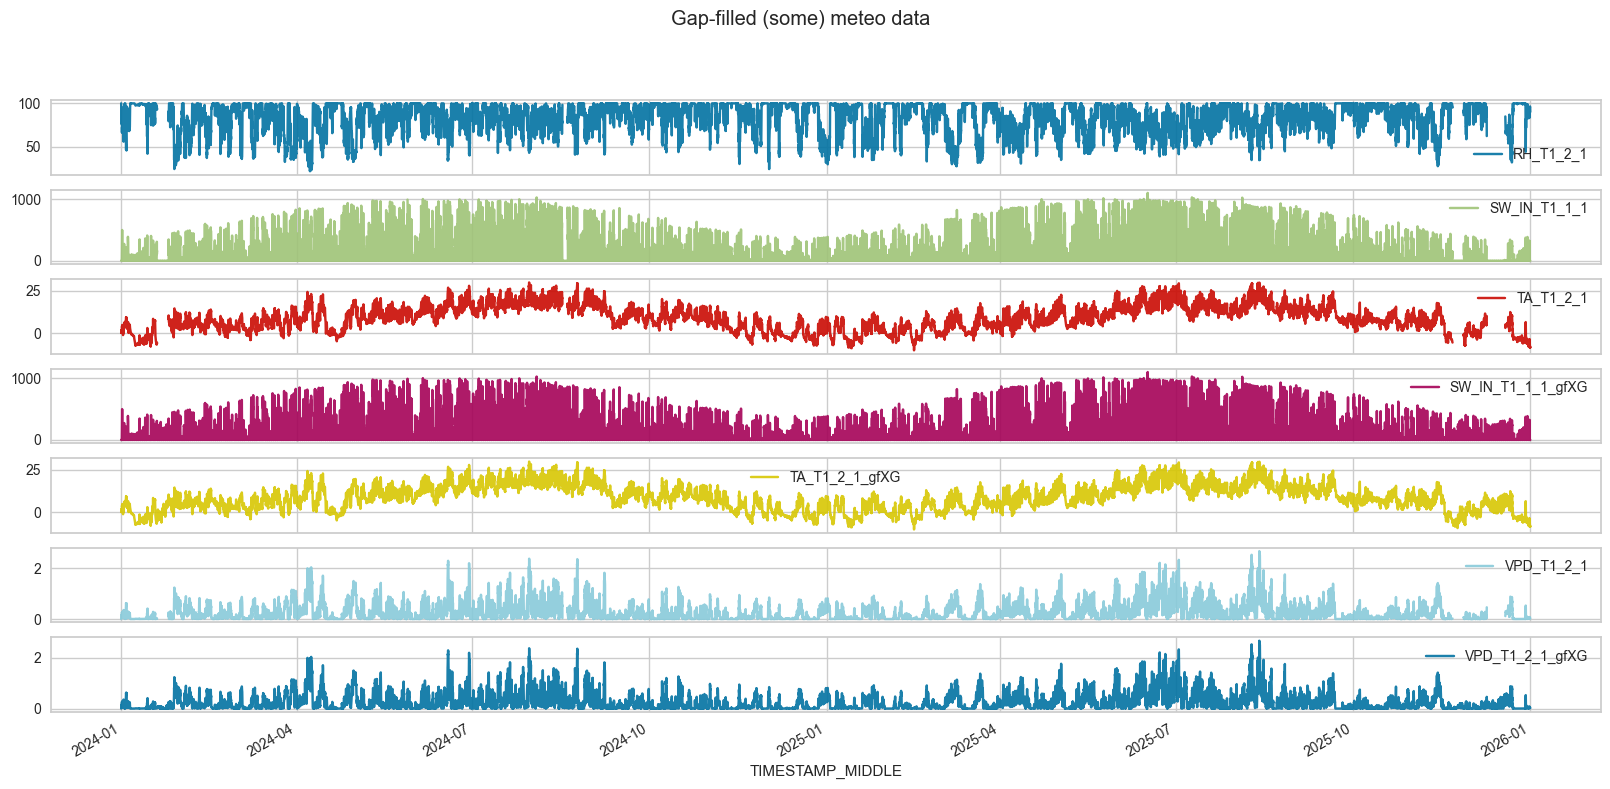

In [51]:
_plot_df = meteo.copy()
_plot_df = _plot_df.replace(-9999, np.nan)
_plot_df.plot(subplots=True, figsize=(20, 9), title="Gap-filled (some) meteo data", alpha=.9, x_compat=True);

# Plot heatmaps

In [52]:
meteo

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG,VPD_T1_2_1,VPD_T1_2_1_gfXG
TIMESTAMP_MIDDLE,,,,,,,
2024-01-01 00:15:00,99.997990,0.0,0.063089,0.0,0.063089,0.000012,0.000012
2024-01-01 00:45:00,98.689082,0.0,0.365761,0.0,0.365761,0.008223,0.008223
2024-01-01 01:15:00,95.548050,0.0,0.326444,0.0,0.326444,0.027846,0.027846
2024-01-01 01:45:00,89.946188,0.0,0.767750,0.0,0.767750,0.064932,0.064932
2024-01-01 02:15:00,85.651175,0.0,1.136206,0.0,1.136206,0.095174,0.095174
...,...,...,...,...,...,...,...
2025-12-31 21:45:00,95.027002,0.0,-8.169633,0.0,-8.169633,0.016381,0.016381
2025-12-31 22:15:00,95.338244,0.0,-8.388672,0.0,-8.388672,0.015095,0.015095
2025-12-31 22:45:00,92.821024,0.0,-8.424472,0.0,-8.424472,0.023180,0.023180


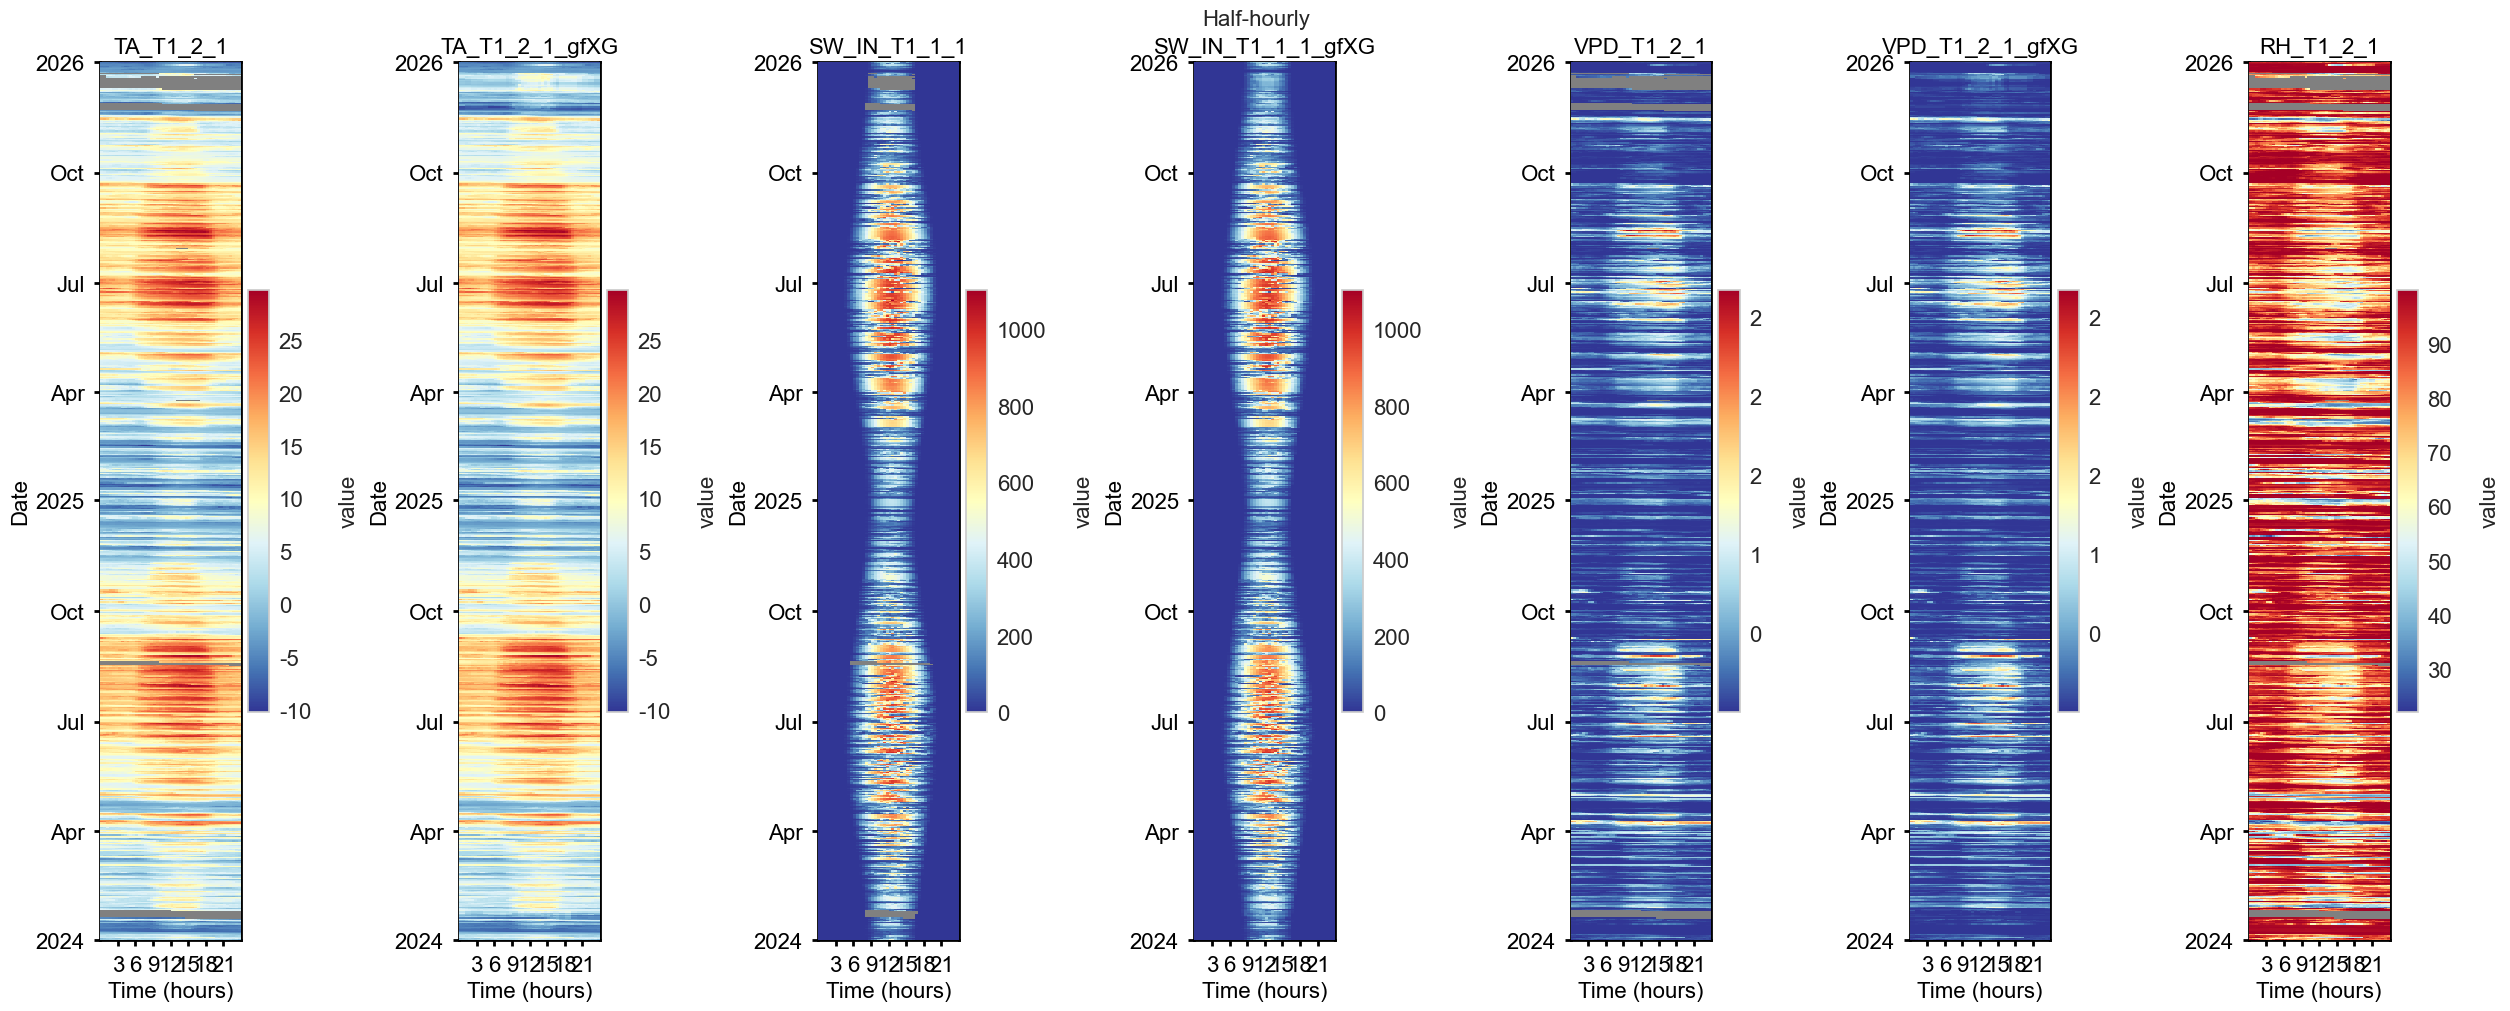

In [53]:
fig, axs = plt.subplots(ncols=7, figsize=(25, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=meteo['TA_T1_2_1'], title="TA_T1_2_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['TA_T1_2_1_gfXG'], title="TA_T1_2_1_gfXG", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['SW_IN_T1_1_1'], title="SW_IN_T1_1_1", ax=axs[2], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['SW_IN_T1_1_1_gfXG'], title="SW_IN_T1_1_1_gfXG", ax=axs[3], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['VPD_T1_2_1'], title="VPD_T1_2_1", ax=axs[4], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['VPD_T1_2_1_gfXG'], title="VPD_T1_2_1_gfXG", ax=axs[5], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo['RH_T1_2_1'], title="RH_T1_2_1", ax=axs[6], cb_digits_after_comma=0, zlabel="value").plot()

</br>

# Stats

In [54]:
meteo.describe()

,RH_T1_2_1,SW_IN_T1_1_1,TA_T1_2_1,SW_IN_T1_1_1_gfXG,TA_T1_2_1_gfXG,VPD_T1_2_1,VPD_T1_2_1_gfXG
count,33865.000000,34647.000000,33865.000000,35088.000000,35088.000000,33865.000000,35088.000000
mean,83.027027,139.358319,8.656682,139.934098,8.436064,0.266297,0.260633
std,17.306447,231.917063,7.433363,231.260334,7.493192,0.351806,0.347890
min,22.063927,0.000000,-10.233528,0.000000,-10.233528,0.000008,0.000008
25%,72.437137,0.000000,3.432522,0.000000,3.134851,0.013451,0.013223
50%,88.318379,1.386259,8.346361,0.000000,8.102733,0.125023,0.120013
75%,98.255546,192.303599,13.900628,194.433048,13.754270,0.384723,0.374153
max,99.997990,1104.207108,29.801215,1104.207108,29.801215,2.676927,2.676927


</br>

# Save to file

In [55]:
OUTNAME = "A4_METEO4_GAPFILLED_2024-2025"
OUTPATH = r""
# filepath = save_parquet(filename=OUTNAME, data=meteo6_2004_2025, outpath=OUTPATH)
meteo.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")

</br>

# End of notebook.

In [56]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-01-20 22:44:21


</br>